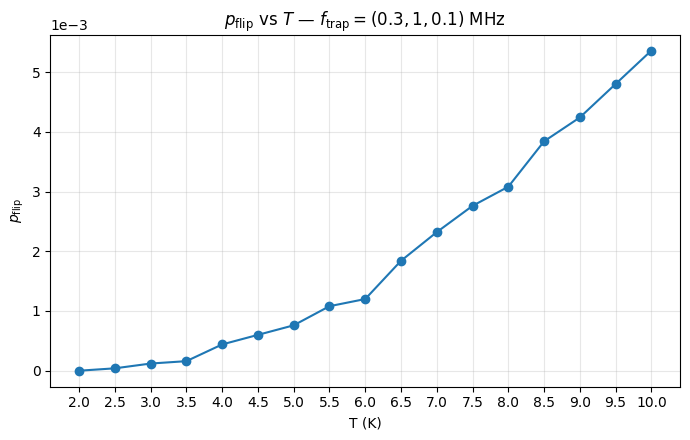

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# === 省频 (axial, radial, radial) MHz ===
trap_freq = (0.3, 1, 0.1)  # MHz

# === 温度 T (K) ===
T_values = np.arange(2, 10.5, 0.5, dtype=float)  # 2, 3, ..., 10 K

# === p_flip 数据 ===
# TODO: 填入每个温度对应的 p_flip 值
p_flip = np.array([
   0,  # T = 2 K
   1, # T = 2.5 K
    3,  # T = 3 K
    4,  # T = 3.5 K
    11,  # T = 4 K
    15,  # T = 4.5 K
    19,  # T = 5 K
    27,  # T = 5.5 K
    30,  # T = 6 K
    46, # T = 6.5 K
    58,  # T = 7 K
    69, # T = 7.5 K
    77,  # T = 8 K
    96, # T = 8.5 K
    106,  # T = 9 K
    120, # T = 9.5 K
    134,  # T = 10 K
])/25000

# === 绘图 ===
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(T_values, p_flip, 'o-', color='tab:blue', markersize=6, linewidth=1.5)

ax.set_xlabel('T (K)')
ax.set_ylabel(r'$p_{\mathrm{flip}}$')
ax.set_title(
    rf'$p_{{\mathrm{{flip}}}}$ vs $T$ — '
    rf'$f_{{\mathrm{{trap}}}}=({trap_freq[0]}, {trap_freq[1]}, {trap_freq[2]})$ MHz'
)
ax.set_xticks(T_values)
ax.grid(True, alpha=0.3)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

fig.tight_layout()
plt.show()

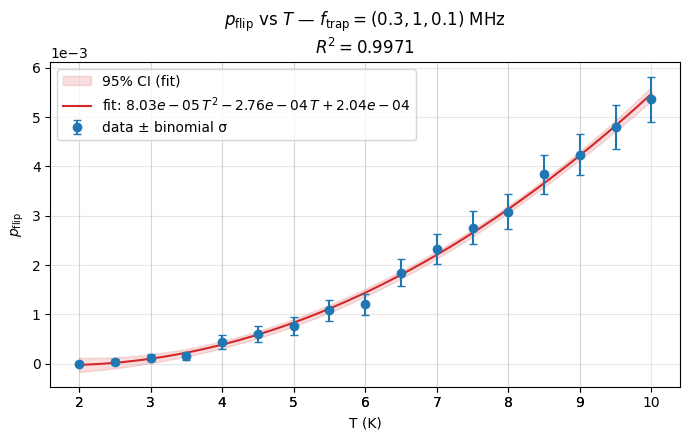

拟合结果: p_flip = 8.0289e-05 * T^2 + (-2.7602e-04) * T + (2.0396e-04)
R² = 0.997127


In [6]:
from scipy import stats

# === 二次多项式拟合: p_flip = a*T^2 + b*T + c ===
coeffs, cov = np.polyfit(T_values, p_flip, 2, cov=True)   # cov=True 取参数协方差
a, b, c = coeffs
p_fit = np.polyval(coeffs, T_values)
dof = len(T_values) - len(coeffs)

# 数据点误差棒: 二项误差 sigma = sqrt(p(1-p)/N), 边界用 Laplace 平滑
N = 25000
p_hat = (p_flip * N + 0.5) / (N + 1)
p_sigma = np.sqrt(p_hat * (1 - p_hat) / N)

# 拟合曲线 95% 置信带 (对均值响应): var(y_hat) = J cov J^T
T_fine = np.linspace(T_values[0], T_values[-1], 200)
p_fit_fine = np.polyval(coeffs, T_fine)
J = np.vander(T_fine, N=len(coeffs))                       # [T^2, T, 1]
se_curve = np.sqrt(np.einsum('ij,jk,ik->i', J, cov, J))
t_crit = stats.t.ppf(0.975, dof)
ci_low, ci_high = p_fit_fine - t_crit * se_curve, p_fit_fine + t_crit * se_curve

# R^2
ss_res = np.sum((p_flip - p_fit) ** 2)
ss_tot = np.sum((p_flip - np.mean(p_flip)) ** 2)
r_squared = 1 - ss_res / ss_tot

# === 绘图 ===
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.fill_between(T_fine, ci_low, ci_high, color='tab:red', alpha=0.15, zorder=1,
                label='95% CI (fit)')
ax.errorbar(T_values, p_flip, yerr=p_sigma, fmt='o', color='tab:blue', markersize=6,
            capsize=3, zorder=3, label='data ± binomial σ')
ax.plot(T_fine, p_fit_fine, '-', color='tab:red', linewidth=1.5, zorder=2,
        label=rf'fit: ${a:.2e}\,T^2 {b:+.2e}\,T {c:+.2e}$')

ax.set_xlabel('T (K)')
ax.set_ylabel(r'$p_{\mathrm{flip}}$')
ax.set_title(
    rf'$p_{{\mathrm{{flip}}}}$ vs $T$ — '
    rf'$f_{{\mathrm{{trap}}}}=({trap_freq[0]}, {trap_freq[1]}, {trap_freq[2]})$ MHz'
    f'\n'
    rf'$R^2 = {r_squared:.4f}$'
)
ax.set_xticks(T_values.astype(int))
ax.legend()
ax.grid(True, alpha=0.3)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

fig.tight_layout()
plt.show()

print(f'拟合结果: p_flip = {a:.4e} * T^2 + ({b:.4e}) * T + ({c:.4e})')
print(f'R² = {r_squared:.6f}')

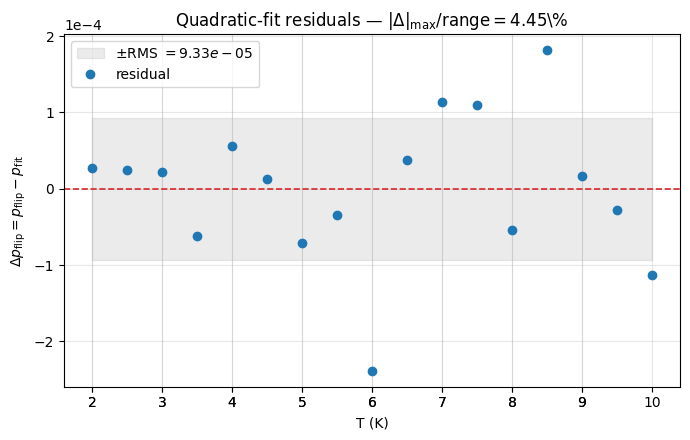

RMS residual    = 9.3273e-05
max |residual|  = 2.3827e-04
data range      = 5.3600e-03
max|res|/range  = 4.4453%


In [5]:
# === 残差分析: residual = p_flip - p_fit (复用上一代码块的拟合) ===
residual = p_flip - p_fit

rms = np.sqrt(np.mean(residual ** 2))
max_abs = np.max(np.abs(residual))
data_range = p_flip.max() - p_flip.min()

fig, ax = plt.subplots(figsize=(7, 4.5))

# ±RMS 误差带 + 零线
ax.fill_between(T_values, -rms, rms, color='tab:gray', alpha=0.15, zorder=1,
                label=rf'$\pm$RMS $= {rms:.2e}$')
ax.axhline(0, color='tab:red', linewidth=1.2, linestyle='--', zorder=2)
ax.plot(T_values, residual, 'o', color='tab:blue', markersize=6, zorder=3,
        label='residual')

ax.set_xlabel('T (K)')
ax.set_ylabel(r'$\Delta p_{\mathrm{flip}} = p_{\mathrm{flip}} - p_{\mathrm{fit}}$')
# mathtext 静态部分放普通 raw string(花括号字面), 数值单独用 raw f-string 相邻拼接,
# 避免 Python<3.12 f-string expression part 含反斜杠的限制, 同时 raw 前缀消除 '\%' 转义警告
ax.set_title(
    r'Quadratic-fit residuals — $|\Delta|_{\max}/\mathrm{range} = $'
    rf'{max_abs / data_range * 100:.2f}\%'
)
ax.set_xticks(T_values.astype(int))
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

fig.tight_layout()
plt.show()

print(f'RMS residual    = {rms:.4e}')
print(f'max |residual|  = {max_abs:.4e}')
print(f'data range      = {data_range:.4e}')
print(f'max|res|/range  = {max_abs/data_range:.4%}')

In [7]:
from scipy import stats

N = 25000
# === 二项误差: sigma_i = sqrt(p(1-p)/N), 边界(p=0/1)用 Laplace 平滑避免 sigma=0 ===
p_hat = (p_flip * N + 0.5) / (N + 1)
sigma = np.sqrt(p_hat * (1 - p_hat) / N)

def wls(T, y, sigma, deg):
    """加权最小二乘多项式 (权重 w = 1/sigma^2 = 1/方差).
    返回 coeffs, 参数协方差, chi2, dof."""
    X = np.vander(T, deg + 1)                 # 列 [x^deg, ..., 1]
    w = 1.0 / sigma ** 2
    XtWX = X.T @ (w[:, None] * X)
    coeffs = np.linalg.solve(XtWX, X.T @ (w * y))
    cov = np.linalg.inv(XtWX)                 # 参数协方差 (权重已含 1/var, 单位正确)
    chi2 = np.sum(((y - X @ coeffs) / sigma) ** 2)
    return coeffs, cov, chi2, len(T) - (deg + 1)

# OLS (原拟合) vs WLS 二次
c_ols = np.polyfit(T_values, p_flip, 2)
c_wls, cov_wls, chi2_w, dof_w = wls(T_values, p_flip, sigma, 2)

print('=== 异方差修正: OLS → WLS (权重 = 1/sigma^2, sigma 为二项误差) ===')
print(f'OLS 系数: a={c_ols[0]:+.4e}, b={c_ols[1]:+.4e}, c={c_ols[2]:+.4e}')
print(f'WLS 系数: a={c_wls[0]:+.4e}, b={c_wls[1]:+.4e}, c={c_wls[2]:+.4e}')

print(f'\n=== 约化卡方 chi2/dof = {chi2_w / dof_w:.3f}  (chi2={chi2_w:.2f}, dof={dof_w}) ===')
print('  ≈1 : 模型与误差自洽')
print('  ≫1 : 拟合不足 (阶数不够) 或 低估误差')
print('  ≪1 : 误差高估')

# WLS 参数 ± 标准误差
se = np.sqrt(np.diag(cov_wls))
for nm, coef, s in zip(['a (T^2)', 'b (T)', 'c'], c_wls, se):
    print(f'  {nm:10s} = {coef:+.4e} ± {s:.4e}  ({coef / s:+.2f}σ)')

=== 异方差修正: OLS → WLS (权重 = 1/sigma^2, sigma 为二项误差) ===
OLS 系数: a=+8.0289e-05, b=-2.7602e-04, c=+2.0396e-04
WLS 系数: a=+8.4274e-05, b=-3.2268e-04, c=+3.1055e-04

=== 约化卡方 chi2/dof = 0.183  (chi2=2.56, dof=14) ===
  ≈1 : 模型与误差自洽
  ≫1 : 拟合不足 (阶数不够) 或 低估误差
  ≪1 : 误差高估
  a (T^2)    = +8.4274e-05 ± 7.6191e-06  (+11.06σ)
  b (T)      = -3.2268e-04 ± 7.0615e-05  (-4.57σ)
  c          = +3.1055e-04 ± 1.2704e-04  (+2.44σ)


In [8]:
# === 阶数检验: 嵌套 F + 三次项 t + AIC/BIC ===
c1, _,    chi2_1, dof1 = wls(T_values, p_flip, sigma, 1)   # 线性
c2, cov2, chi2_2, dof2 = wls(T_values, p_flip, sigma, 2)   # 二次
c3, cov3, chi2_3, dof3 = wls(T_values, p_flip, sigma, 3)   # 三次

def F_test(chi2_restricted, dof_restricted, chi2_full, dof_full):
    """嵌套 F 检验: H0 = 高阶项系数均为 0."""
    d_param = dof_restricted - dof_full
    F = ((chi2_restricted - chi2_full) / d_param) / (chi2_full / dof_full)
    return F, stats.f.sf(F, d_param, dof_full)

F12, p12 = F_test(chi2_1, dof1, chi2_2, dof2)   # 线性 → 二次
F23, p23 = F_test(chi2_2, dof2, chi2_3, dof3)   # 二次 → 三次

print('=== 嵌套 F 检验 (H0: 高阶项系数 = 0) ===')
print(f'线性 → 二次:  F = {F12:8.2f},  p = {p12:.3e}  {"✓ 显著" if p12 < 0.05 else "✗ 不显著"}')
print(f'二次 → 三次:  F = {F23:8.2f},  p = {p23:.3e}  {"✓ 显著" if p23 < 0.05 else "✗ 不显著"}')
print('解读: "线性→二次 显著" 说明二次项必要; '
      '"二次→三次 不显著" 说明三次项多余, 二次阶数充分.')

# 三次项单独 t 检验
c3_coef = c3[0]; se_c3 = np.sqrt(cov3[0, 0])
t_c3 = c3_coef / se_c3
p_t3 = 2 * stats.t.sf(abs(t_c3), dof3)
print(f'\n三次项: c3 = {c3_coef:+.3e} ± {se_c3:.3e},  t = {t_c3:+.3f},  p = {p_t3:.4f}')

# AIC / BIC (基于加权 chi2 ≈ -2 lnL, 越小越好)
n = len(T_values)
print('\n=== 模型选择 (AIC/BIC 越小越好) ===')
for name, chi2, k, dof in [('线性', chi2_1, 2, dof1),
                           ('二次', chi2_2, 3, dof2),
                           ('三次', chi2_3, 4, dof3)]:
    aic = chi2 + 2 * k
    bic = chi2 + k * np.log(n)
    print(f'  {name}:  chi2/dof = {chi2 / dof:6.3f},  AIC = {aic:8.2f},  BIC = {bic:8.2f}')

=== 嵌套 F 检验 (H0: 高阶项系数 = 0) ===
线性 → 二次:  F =   669.36,  p = 3.202e-13  ✓ 显著
二次 → 三次:  F =     0.06,  p = 8.133e-01  ✗ 不显著
解读: "线性→二次 显著" 说明二次项必要; "二次→三次 不显著" 说明三次项多余, 二次阶数充分.

三次项: c3 = -3.893e-07 ± 3.648e-06,  t = -0.107,  p = 0.9167

=== 模型选择 (AIC/BIC 越小越好) ===
  线性:  chi2/dof =  8.327,  AIC =   128.90,  BIC =   130.57
  二次:  chi2/dof =  0.183,  AIC =     8.56,  BIC =    11.06
  三次:  chi2/dof =  0.196,  AIC =    10.55,  BIC =    13.88
